## Data import

Vi finder projektmappen, tilføjer den til sys.path, importerer biblioteker og loader FaultyCase1.mat

Loader Set1_1, Set1_2 og Set1_3 som TimeSeriesDataset-objekter og fault_info gemmer fault-start og fault-end for hvert datasæt

In [ ]:
import sys
from pathlib import Path

cwd = Path.cwd()

while not ((cwd / "data").exists() or (cwd / "CVACaseStudy").exists()):
    if cwd.parent == cwd:
        raise RuntimeError("Kunne ikke finde projekt root")
    cwd = cwd.parent

PROJECT_ROOT = cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor
from fdd.dataset import TimeSeriesDataset

def find_file(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} not found under {root}")
    return sorted(matches, key=lambda p: len(str(p)))[0]

DATA_PATH = find_file(PROJECT_ROOT, "FaultyCase1.mat")

loader = DataLoader(DATA_PATH)
datasets = loader.load()

fault_info = {
    "Set1_1": {"start": 1566, "end": 5181, "description": "Changing conditions"},
    "Set1_2": {"start": 657, "end": 3777, "description": "Steady-state 1"},
    "Set1_3": {"start": 691, "end": 3691, "description": "Steady-state 2"},
}

for name, ds in datasets.items():
    print(name, ds.summary())

PROJECT_ROOT: c:\Users\krist\OneDrive\Skrivebord\Fault detection\Fault-detection-project\Fault-detection-project
DATA_PATH: c:\Users\krist\OneDrive\Skrivebord\Fault detection\Fault-detection-project\Fault-detection-project\data\FaultyCase1.mat
Exists: True

Datasets loaded:
Set1_1: TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)
Set1_2: TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)
Set1_3: TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)

Preview:
   Air_Delivery_P  P_Bottom_Riser  P_Top_Riser  P_Top_Separator  \
0        0.123671        0.118994     0.099840         0.102702   
1        0.123146        0.118504     0.099780         0.102566   
2        0.122749        0.118401     0.099980         0.102515   
3        0.122648        0.118266     0.100266         0.102741   
4        0.122463        0.117908     0.100248         0.103059   

   P_3Phase_Separator  Diff_P_Riser  Diff_P_VC404  Air_In_Flow  Water_In_Flow  \
0            0.099423

## Evalueringsfunktioner

Definerer målene til evaluering, laver en sand/falsk label serie, hvor 0 = normal og 1 = fault.

Beregner 
- Første alarm efter fault-start
- Detection delay
- Antal alarmer før, under og efter fault
- False alarm rate
- Fault detection rate 

Mest relevant for FDA, ikke så vigtig for PCA

In [9]:
def make_ground_truth(n_samples, fault_start, fault_end):
    y = np.zeros(n_samples, dtype=int)
    y[fault_start:fault_end + 1] = 1
    return y


def evaluate_alarm(alarm, fault_start, fault_end):
    alarm = np.asarray(alarm).astype(bool)

    before_fault = alarm[:fault_start]
    during_fault = alarm[fault_start:fault_end + 1]
    after_fault = alarm[fault_end + 1:]

    alarm_indices_after_start = np.where(alarm[fault_start:])[0]

    if len(alarm_indices_after_start) == 0:
        first_alarm_after_fault = None
        detection_delay = None
    else:
        first_alarm_after_fault = int(alarm_indices_after_start[0] + fault_start)
        detection_delay = int(first_alarm_after_fault - fault_start)

    return {
        "first_alarm_after_fault": first_alarm_after_fault,
        "detection_delay": detection_delay,
        "n_alarms_total": int(alarm.sum()),
        "n_alarms_before_fault": int(before_fault.sum()),
        "n_alarms_during_fault": int(during_fault.sum()),
        "n_alarms_after_fault": int(after_fault.sum()),
        "false_alarm_rate_before_fault": float(before_fault.mean()) if len(before_fault) else np.nan,
        "fault_detection_rate": float(during_fault.mean()) if len(during_fault) else np.nan,
    }


def evaluate_classifier(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_fault": precision_score(y_true, y_pred, zero_division=0),
        "recall_fault": recall_score(y_true, y_pred, zero_division=0),
        "f1_fault": f1_score(y_true, y_pred, zero_division=0),
    }

## Datatjek 

Denne blok kontrollerer, at data er loaded korrekt. 

Den viser: 
- Datasættets navn
- Antal samples 
- Antal features 
- De første rækker af sensor data 



In [10]:
for name, dataset in datasets.items():
    print(dataset.summary())
    display(dataset.sensors.head())

TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.123671,0.118994,0.099840,0.102702,0.099423,0.019198,0.248773,0.020653,0.493771,-0.246817,...,995.862488,996.525513,20.018761,20.923019,21.754801,7.324118,21.015640,46.294441,28.072460,2.1050
1,0.123146,0.118504,0.099780,0.102566,0.099522,0.018732,0.288827,0.020645,0.493793,-0.246817,...,995.862610,996.518677,20.015230,20.922810,21.761770,7.321606,21.023270,46.311249,28.073271,2.0150
2,0.122749,0.118401,0.099980,0.102515,0.099621,0.018358,0.270946,0.020638,0.493816,-0.246818,...,995.862793,996.511780,20.011700,20.922609,21.768749,7.319094,21.035440,46.328072,28.074089,1.9175
3,0.122648,0.118266,0.100266,0.102741,0.099721,0.018015,0.240905,0.020636,0.493838,-0.246819,...,995.862976,996.505005,20.008169,20.922409,21.775721,7.316582,21.047621,46.344879,28.074909,1.9150
4,0.122463,0.117908,0.100248,0.103059,0.099792,0.017672,0.271661,0.020635,0.493860,-0.246819,...,995.863098,996.498230,20.004641,20.922199,21.782700,7.314071,21.059790,46.361698,28.075729,2.1375


TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.134422,0.128272,0.102251,0.104552,0.099477,0.026017,0.395401,0.041172,1.988174,0.345307,...,987.024170,997.685425,20.788589,19.79677,19.106760,35.205521,27.12253,88.334503,43.250599,2.2100
1,0.134377,0.128434,0.102302,0.104471,0.099487,0.026034,0.470502,0.041136,1.989220,0.128820,...,987.656128,997.685486,20.789459,19.79862,18.965611,35.207569,27.11714,88.385307,43.258072,2.2900
2,0.134632,0.128661,0.102409,0.104656,0.099497,0.026203,0.429733,0.041123,1.992013,0.014496,...,988.288086,997.685486,20.790331,19.80048,18.918560,35.209610,27.11174,88.436111,43.265541,2.1000
3,0.134634,0.128690,0.102516,0.104800,0.099507,0.026164,0.316007,0.041084,1.994807,0.458081,...,988.919983,997.685486,20.791210,19.80234,18.918560,35.211651,27.10635,88.486923,43.273010,1.9975
4,0.134763,0.128653,0.102623,0.104902,0.099517,0.026040,0.292404,0.041065,1.997600,0.412542,...,989.552002,997.685608,20.792080,19.80419,18.918560,35.213699,27.10095,88.537727,43.280479,2.1775


TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.148614,0.144112,0.099908,0.102331,0.099692,0.044019,0.657899,0.021139,3.493562,-0.119259,...,278.099609,998.15802,21.240061,21.056549,20.549940,34.029011,20.176050,47.243179,56.314251,2.4075
1,0.148712,0.144223,0.099980,0.102346,0.099749,0.044139,0.664337,0.021129,3.493410,-0.204256,...,274.954712,998.15802,21.240170,21.055470,20.549940,34.016430,20.188910,47.229820,56.316959,2.4150
2,0.148811,0.144334,0.100075,0.102346,0.099805,0.044162,0.675781,0.021120,3.493258,-0.246815,...,278.543915,998.15802,21.240280,21.054399,20.549940,34.003399,20.201780,47.216461,56.319679,2.3925
3,0.148909,0.144444,0.100153,0.102410,0.099861,0.044153,0.700099,0.021112,3.493105,-0.122358,...,280.331696,998.15802,21.240391,21.053320,20.597019,33.990379,20.214649,47.203110,56.322392,2.4950
4,0.149008,0.144440,0.100224,0.102479,0.099917,0.044143,0.709398,0.021104,3.492953,-0.041533,...,285.598602,998.15802,21.240490,21.052250,20.612711,33.977360,20.227510,47.189751,56.325100,2.5000


## Healthy training datasæt

Denne blok samler alle raske samples før fault-start. For hvert datasæt tager den kun perioden før fejlen starter. Derefter samles de og pakkes ind i sin egen klasse. Det er godt, fordi PCA skal lære normal drift, ikke fault data.

In [11]:
healthy_parts = []

for name, dataset in datasets.items():
    fault_start = fault_info[name]["start"]
    healthy_parts.append(dataset.subset_rows(0, fault_start).sensors)

healthy_sensors = pd.concat(healthy_parts, ignore_index=True)

healthy_dataset = TimeSeriesDataset(
    name="Healthy_training_data",
    sensors=healthy_sensors,
    metadata={"description": "All samples before fault start"},
)

display(healthy_dataset.sensors.head())

,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.123671,0.118994,0.099840,0.102702,0.099423,0.019198,0.248773,0.020653,0.493771,-0.246817,...,995.862488,996.525513,20.018761,20.923019,21.754801,7.324118,21.015640,46.294441,28.072460,2.1050
1,0.123146,0.118504,0.099780,0.102566,0.099522,0.018732,0.288827,0.020645,0.493793,-0.246817,...,995.862610,996.518677,20.015230,20.922810,21.761770,7.321606,21.023270,46.311249,28.073271,2.0150
2,0.122749,0.118401,0.099980,0.102515,0.099621,0.018358,0.270946,0.020638,0.493816,-0.246818,...,995.862793,996.511780,20.011700,20.922609,21.768749,7.319094,21.035440,46.328072,28.074089,1.9175
3,0.122648,0.118266,0.100266,0.102741,0.099721,0.018015,0.240905,0.020636,0.493838,-0.246819,...,995.862976,996.505005,20.008169,20.922409,21.775721,7.316582,21.047621,46.344879,28.074909,1.9150
4,0.122463,0.117908,0.100248,0.103059,0.099792,0.017672,0.271661,0.020635,0.493860,-0.246819,...,995.863098,996.498230,20.004641,20.922199,21.782700,7.314071,21.059790,46.361698,28.075729,2.1375


## Standardisering

Her bruges StandardPreprocessor, det betyder: 
- Data standardiseres 
- Der bruges ingen lagged features 
- Manglende værdier droppes 

Preprocessoren lærer middelværdi og standardafvigelse fra healthy data og konverterer data til NumPy, så PCA kan beregnes matematisk

In [12]:
preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=0,
    drop_na=True,
)

healthy_scaled = preprocessor.fit_transform(healthy_dataset)
X_train = healthy_scaled.to_numpy()

print("X_train shape:", X_train.shape)

X_train shape: (2914, 23)


## PCA eigenvalue decomposition 

Denne blok træner selve PCA-modellen og beregner kovariansmatricen mellem sensorene og finder principal components. Derefter sorteres komponenterne, så den vigtigste kommer først. 

Til sidst laves en tabel, som viser:
- Komponentnummer
- Eigenvalue
- Explained variance ratio
- Cumulative variance 

Denne tabel er meget god til rapporten, fordi den forklarer valget af antal PCA-komponenter. 


In [13]:
cov_matrix = np.cov(X_train.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

pca_variance_df = pd.DataFrame({
    "component": np.arange(1, len(eigenvalues) + 1),
    "eigenvalue": eigenvalues,
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_variance": cumulative_variance,
})

display(pca_variance_df.head(12))

,component,eigenvalue,explained_variance_ratio,cumulative_variance
0,1,8.863083,0.385219,0.385219
1,2,6.126112,0.266261,0.651480
2,3,2.495073,0.108444,0.759925
3,4,1.814668,0.078872,0.838796
4,5,1.078119,0.046859,0.885655
5,6,0.941334,0.040914,0.926568
6,7,0.903512,0.039270,0.965838
7,8,0.213595,0.009284,0.975122
8,9,0.143242,0.006226,0.981347
9,10,0.105903,0.004603,0.985950


## Scree plot og cumulative variance plot

Denne blok laver to vigtige PCA-grafer. 
Første graf viser hvor meget hver principal komponent forklarer. 

Anden graf viser hvor meget varians der forklares samlet. De vandrettte linjer ved 80% og 90% hjælper med at vurdere, hvor mange komponenter man bør vælge

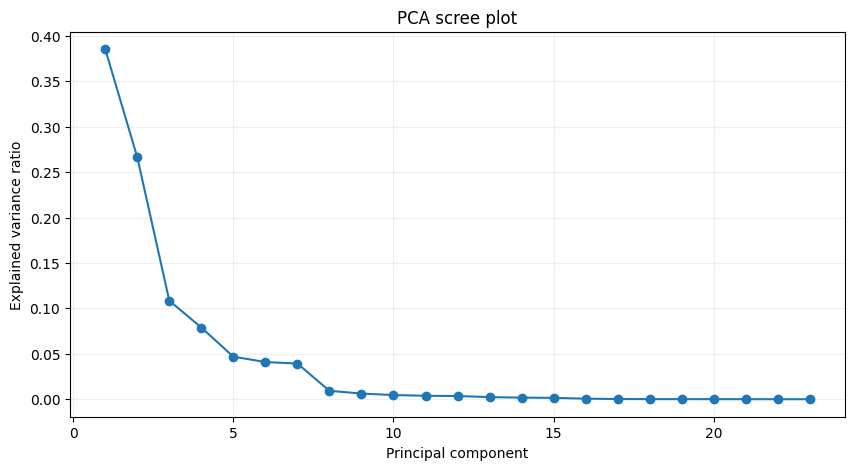

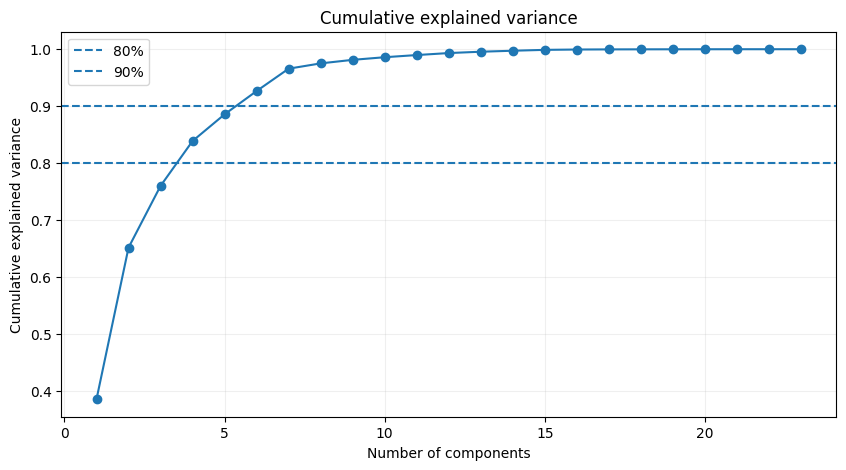

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(pca_variance_df["component"], pca_variance_df["explained_variance_ratio"], marker="o")
plt.title("PCA scree plot")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(pca_variance_df["component"], pca_variance_df["cumulative_variance"], marker="o")
plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.90, linestyle="--", label="90%")
plt.title("Cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

In [20]:
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
print("Components needed for 90% variance:", n_90)

Components needed for 90% variance: 6


## Vælg PCA-komponenter og beregn T2-threshold

Her vælges n_components, hvor modellen bruger de første 7 principal components, siden det kræver mere end 6 principal components for at have +90% variance.

Hvis T2 overskrider kontrolgrænsen, giver PCA modellen alarm. 

In [ ]:
from scipy.stats import f

n_components = 7

P = eigenvectors[:, :n_components] # PCA-loading matrice
lambda_inv = np.diag(1.0 / eigenvalues[:n_components]) # Hotelling's T2 bruger den inverse af de valgte eigenvalues

n = X_train.shape[0]
a = n_components
alpha = 0.05

F_limit = f.ppf(1 - alpha, a, n - a)
T2_limit = (a * (n - 1) * (n + 1)) / (n * (n - a)) * F_limit # Kontrolgrænse for Hotelling's T2

print("T2 threshold:", T2_limit)

T2 threshold: 14.123018031348115


## PCA detection funktion 

Denne funktion bruges til at teste nye datasæt, den standardiserer testdata med samme middelværdi og standardafivgelse som training data. Den projekterer data ind i PCA rummet og beregner Hotelling T2-score for hvert sample og giver alarm, når T2 er over threshold. 

Funktionen returnerer:
- T2 
- Alarm
- Scores

In [ ]:
def pca_detect(dataset):
    dataset_scaled = preprocessor.transform(dataset)
    X = dataset_scaled.to_numpy()

    scores = X @ P # PCA-scores (projektion af data på de valgte principal components)
    T2 = np.sum((scores @ lambda_inv) * scores, axis=1) # Hotelling's T2 beregnes som sum af (score^2 / eigenvalue) for de valgte komponenter

    alarm = T2 > T2_limit # Alarm udløses, hvis T2 overstiger kontrolgrænsen

    return T2, alarm, scores

## PCA fault detection plot 

Denne blok kører PCA på alle tre datasæt, for hvert datasæt gemmes resultaterne i pca_results. 

Grafen viser: 
- Hotelling T2 over tid
- Threshold
- Fault-start 
- Fault-end

Det er hovedgrafen for PCA-metoden

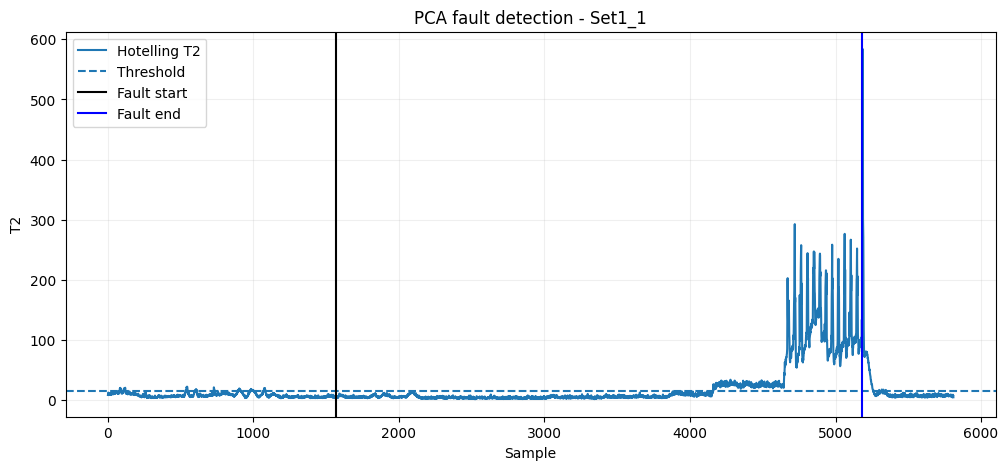

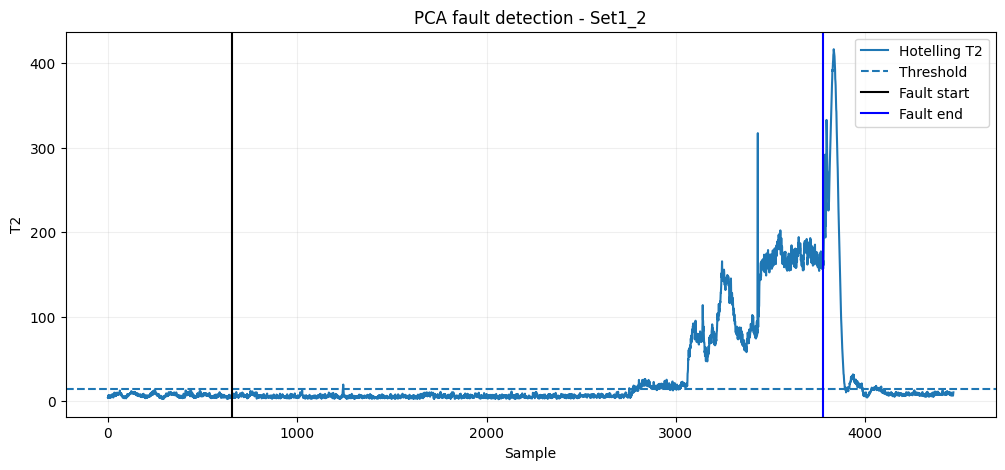

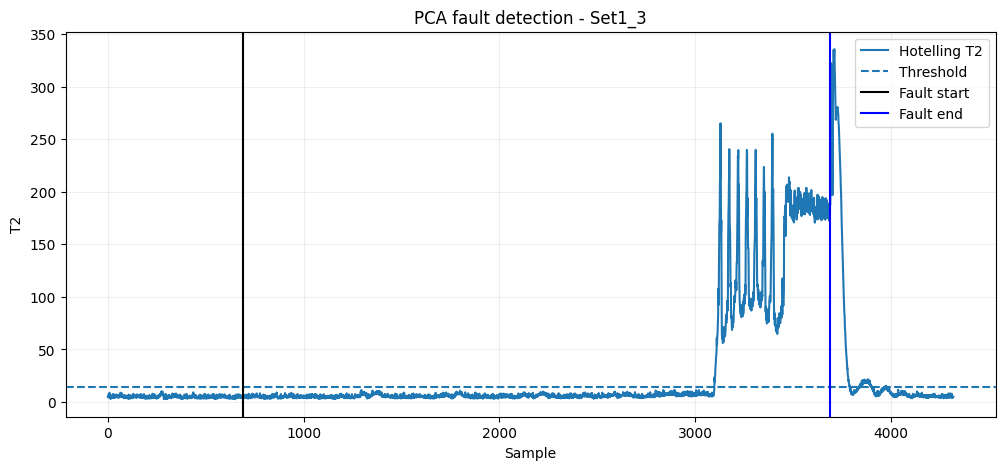

In [17]:
pca_results = {}

for name, dataset in datasets.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    T2, alarm, scores = pca_detect(dataset)

    pca_results[name] = {
        "T2": T2,
        "alarm": alarm,
        "scores": scores,
    }

    plt.figure(figsize=(12, 5))
    plt.plot(T2, label="Hotelling T2")
    plt.axhline(T2_limit, linestyle="--", label="Threshold")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"PCA fault detection - {name}")
    plt.xlabel("Sample")
    plt.ylabel("T2")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## Binær alarmgraf

Denne blok viser alarmen som 0/1 over tid. Det gør det lettere at se præcist, hvornår modellen giver alarm. Denne graf er især god sammen med evalueringstabellen. 

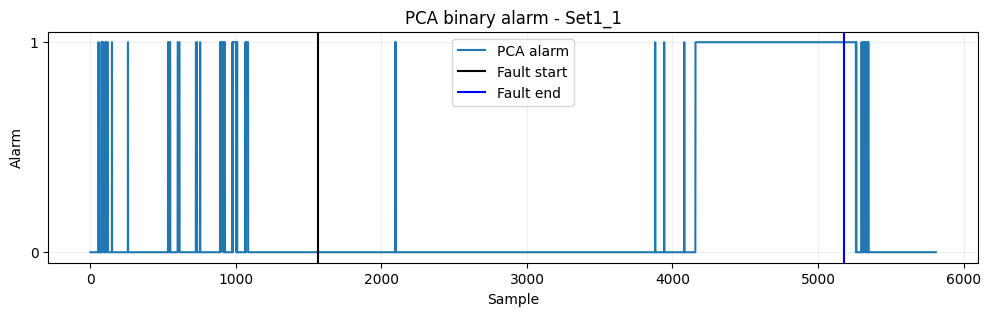

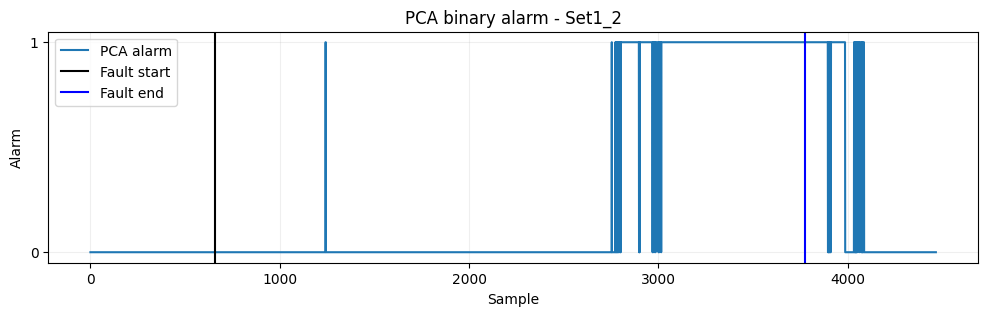

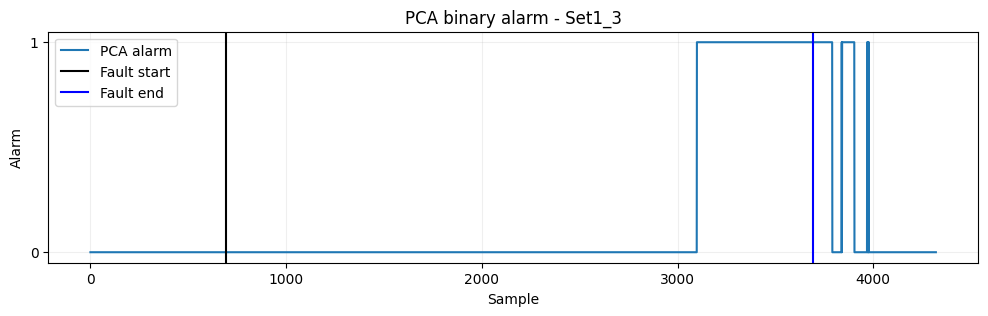

In [18]:
for name, result in pca_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 3))
    plt.plot(result["alarm"].astype(int), label="PCA alarm")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"PCA binary alarm - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Alarm")
    plt.yticks([0, 1])
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## PCA summary table 

Denne blok evaluerer PCA for hvert datasæt og beregner performance-mål. 

Tabellen viser blandt andet: 
- First alarm after fault
- Detection delay
- Total alarms 
- False alarm rate 
- Fault detection rate 

Det er den vigtigste tabel til sammenligning med Shewhart og FDA

In [19]:
pca_rows = []

for name, result in pca_results.items():
    metrics = evaluate_alarm(
        result["alarm"],
        fault_info[name]["start"],
        fault_info[name]["end"],
    )

    pca_rows.append({
        "Dataset": name,
        "Model": f"PCA T2 ({n_components} components)",
        **metrics,
    })

pca_summary_df = pd.DataFrame(pca_rows)
display(pca_summary_df)

,Dataset,Model,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_during_fault,n_alarms_after_fault,false_alarm_rate_before_fault,fault_detection_rate
0,Set1_1,PCA T2 (7 components),2095,529,1265,133,1029,103,0.08493,0.284569
1,Set1_2,PCA T2 (7 components),1242,585,1220,0,988,232,0.00000,0.316565
2,Set1_3,PCA T2 (7 components),3099,2408,760,0,593,167,0.00000,0.197601
